# 🏬 Multi-Dimensional Retail Analytics on Istanbul Shopping Data

**Level:** Advanced

**Objective:** Conduct a thorough analytical deep-dive into Istanbul shopping mall data, examining customer demographics, spending patterns and yearly trends across multiple dimensions simultaneously.

**Tools:** pandas, matplotlib, seaborn

---

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [2]:
# Load dataset
df = pd.read_csv('customer_shopping_data.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col} ({df[col].dtype})')

df.head(10)

Dataset shape: 99,457 rows × 10 columns

Columns:
  1. invoice_no (object)
  2. customer_id (object)
  3. gender (object)
  4. age (int64)
  5. category (object)
  6. quantity (int64)
  7. price (float64)
  8. payment_method (object)
  9. invoice_date (object)
  10. shopping_mall (object)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,24/05/2022,Forum Istanbul
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul
8,I293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity
9,I326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon


## 2. Data Quality Check

In [3]:
print('='*60)
print('DATA TYPES')
print('='*60)
print(df.dtypes)

print('\n' + '='*60)
print('MISSING VALUES')
print('='*60)
missing = df.isnull().sum()
print(missing)
print(f'\n✅ Total missing values: {missing.sum()}')

print('\n' + '='*60)
print('DUPLICATE ROWS')
print('='*60)
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n' + '='*60)
print('DESCRIPTIVE STATISTICS')
print('='*60)
df.describe().round(2)

DATA TYPES
invoice_no         object
customer_id        object
gender             object
age                 int64
category           object
quantity            int64
price             float64
payment_method     object
invoice_date       object
shopping_mall      object
dtype: object

MISSING VALUES
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

✅ Total missing values: 0

DUPLICATE ROWS
Duplicate rows: 0

DESCRIPTIVE STATISTICS


,age,quantity,price
count,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26
std,14.99,1.41,941.18
min,18.00,1.00,5.23
25%,30.00,2.00,45.45
50%,43.00,3.00,203.30
75%,56.00,4.00,1200.32
max,69.00,5.00,5250.00


In [4]:
# Unique values in categorical columns
cat_cols = ['gender', 'category', 'payment_method', 'shopping_mall']

print('UNIQUE VALUES IN CATEGORICAL COLUMNS')
print('='*60)
for col in cat_cols:
    print(f'\n{col}: {df[col].nunique()} unique')
    print(f'  → {df[col].unique().tolist()}')

UNIQUE VALUES IN CATEGORICAL COLUMNS

gender: 2 unique
  → ['Female', 'Male']

category: 8 unique
  → ['Clothing', 'Shoes', 'Books', 'Cosmetics', 'Food & Beverage', 'Toys', 'Technology', 'Souvenir']

payment_method: 3 unique
  → ['Credit Card', 'Debit Card', 'Cash']

shopping_mall: 10 unique
  → ['Kanyon', 'Forum Istanbul', 'Metrocity', 'Metropol AVM', 'Istinye Park', 'Mall of Istanbul', 'Emaar Square Mall', 'Cevahir AVM', 'Viaport Outlet', 'Zorlu Center']


## 3. Data Preprocessing

Convert `invoice_date` to datetime and extract **year** and **month** features.

In [5]:
# Convert invoice_date to datetime
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

# Extract year and month
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['month_name'] = df['invoice_date'].dt.month_name()
df['year_month'] = df['invoice_date'].dt.to_period('M')

print('✅ Date conversion complete')
print(f'Date range: {df["invoice_date"].min().strftime("%Y-%m-%d")} → {df["invoice_date"].max().strftime("%Y-%m-%d")}')
print(f'Years covered: {sorted(df["year"].unique())}')

df[['invoice_no', 'invoice_date', 'year', 'month', 'month_name']].head()

✅ Date conversion complete
Date range: 2021-01-01 → 2023-03-08
Years covered: [np.int32(2021), np.int32(2022), np.int32(2023)]


,invoice_no,invoice_date,year,month,month_name
0,I138884,2022-08-05,2022,8,August
1,I317333,2021-12-12,2021,12,December
2,I127801,2021-11-09,2021,11,November
3,I173702,2021-05-16,2021,5,May
4,I337046,2021-10-24,2021,10,October


## 4. Spending Analysis by Category, Mall, Payment & Gender

In [6]:
# ─── 4.1 Spending by CATEGORY ───
category_analysis = df.groupby('category').agg(
    Total_Revenue=('price', 'sum'),
    Order_Count=('invoice_no', 'count'),
    Avg_Purchase=('price', 'mean'),
    Avg_Quantity=('quantity', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

# Revenue share %
category_analysis['Revenue_Share_%'] = (
    category_analysis['Total_Revenue'] / category_analysis['Total_Revenue'].sum() * 100
).round(2)

print('📊 SPENDING ANALYSIS BY CATEGORY')
print('='*80)
category_analysis

📊 SPENDING ANALYSIS BY CATEGORY


,Total_Revenue,Order_Count,Avg_Purchase,Avg_Quantity,Revenue_Share_%
category,,,,,
Clothing,31075684.64,34487,901.08,3.00,45.33
Shoes,18135336.89,10034,1807.39,3.01,26.46
Technology,15772050.00,4996,3156.94,3.01,23.01
Cosmetics,1848606.90,15097,122.45,3.01,2.70
Toys,1086704.64,10087,107.73,3.01,1.59
Food & Beverage,231568.71,14776,15.67,3.00,0.34
Books,226977.30,4981,45.57,3.01,0.33
Souvenir,174436.83,4999,34.89,2.97,0.25


In [7]:
# ─── 4.2 Spending by SHOPPING MALL ───
mall_analysis = df.groupby('shopping_mall').agg(
    Total_Revenue=('price', 'sum'),
    Order_Count=('invoice_no', 'count'),
    Avg_Purchase=('price', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print('📊 SPENDING ANALYSIS BY SHOPPING MALL')
print('='*70)
mall_analysis

📊 SPENDING ANALYSIS BY SHOPPING MALL


,Total_Revenue,Order_Count,Avg_Purchase
shopping_mall,,,
Mall of Istanbul,13851737.62,19943,694.57
Kanyon,13710755.24,19823,691.66
Metrocity,10249980.07,15011,682.83
Metropol AVM,6937992.99,10161,682.81
Istinye Park,6717077.54,9781,686.75
Zorlu Center,3509649.02,5075,691.56
Cevahir AVM,3433671.84,4991,687.97
Viaport Outlet,3414019.46,4914,694.75
Emaar Square Mall,3390408.31,4811,704.72


In [8]:
# ─── 4.3 Spending by PAYMENT METHOD ───
payment_analysis = df.groupby('payment_method').agg(
    Total_Revenue=('price', 'sum'),
    Order_Count=('invoice_no', 'count'),
    Avg_Purchase=('price', 'mean'),
    Share_Pct=('invoice_no', lambda x: round(len(x)/len(df)*100, 2))
).round(2).sort_values('Order_Count', ascending=False)

print('📊 SPENDING ANALYSIS BY PAYMENT METHOD')
print('='*70)
payment_analysis

📊 SPENDING ANALYSIS BY PAYMENT METHOD


,Total_Revenue,Order_Count,Avg_Purchase,Share_Pct
payment_method,,,,
Cash,30705030.98,44447,690.82,44.69
Credit Card,24051476.93,34931,688.54,35.12
Debit Card,13794858.00,20079,687.03,20.19


In [9]:
# ─── 4.4 Spending by GENDER ───
gender_analysis = df.groupby('gender').agg(
    Total_Revenue=('price', 'sum'),
    Order_Count=('invoice_no', 'count'),
    Avg_Purchase=('price', 'mean'),
    Share_Pct=('invoice_no', lambda x: round(len(x)/len(df)*100, 2))
).round(2)

print('📊 SPENDING ANALYSIS BY GENDER')
print('='*70)
gender_analysis

📊 SPENDING ANALYSIS BY GENDER


,Total_Revenue,Order_Count,Avg_Purchase,Share_Pct
gender,,,,
Female,40931801.62,59482,688.14,59.81
Male,27619564.29,39975,690.92,40.19


## 5. Average Purchase Amount per Category & Revenue Ranking

In [10]:
# Average purchase & ranking
avg_purchase = df.groupby('category')['price'].agg(['mean', 'median', 'sum', 'count'])
avg_purchase.columns = ['Avg_Purchase', 'Median_Purchase', 'Total_Revenue', 'Transaction_Count']
avg_purchase = avg_purchase.sort_values('Total_Revenue', ascending=False).round(2)
avg_purchase['Rank'] = range(1, len(avg_purchase) + 1)

print('🏆 CATEGORY RANKING BY TOTAL REVENUE')
print('='*80)
for _, row in avg_purchase.iterrows():
    rank = int(row['Rank'])
    marker = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else '  '))
    print(f'{marker} {rank}. {_:<25} Revenue: ${row["Total_Revenue"]:>15,.2f}  |  Avg: ${row["Avg_Purchase"]:>8,.2f}  |  Orders: {int(row["Transaction_Count"]):>6,}')

print(f'\nHighest avg purchase: Technology (${avg_purchase.loc["Technology", "Avg_Purchase"]:,.2f})')
print(f'Lowest avg purchase:  Food & Beverage (${avg_purchase.loc["Food & Beverage", "Avg_Purchase"]:,.2f})')

🏆 CATEGORY RANKING BY TOTAL REVENUE
🥇 1. Clothing                  Revenue: $  31,075,684.64  |  Avg: $  901.08  |  Orders: 34,487
🥈 2. Shoes                     Revenue: $  18,135,336.89  |  Avg: $1,807.39  |  Orders: 10,034
🥉 3. Technology                Revenue: $  15,772,050.00  |  Avg: $3,156.94  |  Orders:  4,996
   4. Cosmetics                 Revenue: $   1,848,606.90  |  Avg: $  122.45  |  Orders: 15,097
   5. Toys                      Revenue: $   1,086,704.64  |  Avg: $  107.73  |  Orders: 10,087
   6. Food & Beverage           Revenue: $     231,568.71  |  Avg: $   15.67  |  Orders: 14,776
   7. Books                     Revenue: $     226,977.30  |  Avg: $   45.57  |  Orders:  4,981
   8. Souvenir                  Revenue: $     174,436.83  |  Avg: $   34.89  |  Orders:  4,999

Highest avg purchase: Technology ($3,156.94)
Lowest avg purchase:  Food & Beverage ($15.67)


## 6. Pivot Table: Shopping Mall vs Category → Total Revenue

In [11]:
# Cross-tabulation pivot table
pivot_table = pd.pivot_table(
    df,
    values='price',
    index='shopping_mall',
    columns='category',
    aggfunc='sum'
).round(2)

# Add row totals
pivot_table['TOTAL'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values('TOTAL', ascending=False)

print('📊 PIVOT TABLE: Shopping Mall × Category (Total Revenue $)')
print('='*120)
pivot_table

📊 PIVOT TABLE: Shopping Mall × Category (Total Revenue $)


category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys,TOTAL
shopping_mall,,,,,,,,,
Mall of Istanbul,46949.85,6245565.04,373787.38,46431.94,3668239.04,34263.33,3220350.0,216151.04,13851737.62
Kanyon,44980.35,6155541.04,372242.30,45474.85,3640031.05,35483.25,3202500.0,214502.40,13710755.24
Metrocity,34405.65,4719958.32,272422.00,35375.72,2610139.33,25770.81,2386650.0,165258.24,10249980.07
Metropol AVM,22240.20,3166444.16,185775.54,23984.78,1942750.29,18603.78,1465800.0,112394.24,6937992.99
Istinye Park,20725.20,3050313.20,178741.36,23419.94,1806511.70,18369.18,1509900.0,109096.96,6717077.54
Zorlu Center,12256.35,1568818.24,96974.10,11589.68,953670.13,8398.68,803250.0,54691.84,3509649.02
Cevahir AVM,11998.80,1554414.40,88394.84,11992.39,884050.41,8304.84,819000.0,55516.16,3433671.84
Viaport Outlet,10908.00,1530708.08,92664.14,11432.78,882850.07,7636.23,823200.0,54620.16,3414019.46
Emaar Square Mall,11059.50,1511803.04,92379.52,11030.07,871446.84,8515.98,834750.0,49423.36,3390408.31


## 7. Yearly Revenue Trend Analysis (2021–2023)

In [12]:
# Yearly revenue by category
yearly_category = df.groupby(['year', 'category'])['price'].sum().unstack().round(2)

print('📊 YEARLY REVENUE BY CATEGORY')
print('='*90)
print(yearly_category.to_string())

# Year-over-year growth
print('\n📈 YEAR-OVER-YEAR GROWTH (%)')
print('='*90)
yoy_growth = yearly_category.pct_change().multiply(100).round(2)
print(yoy_growth.to_string())

📊 YEARLY REVENUE BY CATEGORY
category      Books     Clothing  Cosmetics  Food & Beverage       Shoes  Souvenir  Technology       Toys
year                                                                                                     
2021      100065.75  14365129.68  828081.56        106179.46  8242134.61  79118.85   7104300.0  491294.72
2022      106822.65  14070451.12  855405.08        105876.12  8378373.20  80948.73   7268100.0  506849.28
2023       20088.90   2640103.84  165120.26         19513.13  1514829.08  14369.25   1399650.0   88560.64

📈 YEAR-OVER-YEAR GROWTH (%)
category  Books  Clothing  Cosmetics  Food & Beverage  Shoes  Souvenir  Technology   Toys
year                                                                                     
2021        NaN       NaN        NaN              NaN    NaN       NaN         NaN    NaN
2022       6.75     -2.05        3.3            -0.29   1.65      2.31        2.31   3.17
2023     -81.19    -81.24      -80.7           -81.5

## 8. Demographic Analysis: Male vs Female Spending

In [13]:
# Gender spending comparison across categories
gender_category = df.groupby(['gender', 'category']).agg(
    Total_Revenue=('price', 'sum'),
    Avg_Purchase=('price', 'mean'),
    Order_Count=('invoice_no', 'count')
).round(2)

print('📊 GENDER VS CATEGORY SPENDING')
print('='*80)
gender_category

📊 GENDER VS CATEGORY SPENDING


Total_Revenue  Avg_Purchase  Order_Count
gender category                                                 
Female Books                132956.40         45.75         2906
       Clothing           18616663.12        901.45        20652
       Cosmetics           1108432.26        122.21         9070
       Food & Beverage      137873.26         15.66         8804
       Shoes              10746644.02       1801.01         5967
       Souvenir             105288.48         34.90         3017
       Technology          9425850.00       3161.98         2981
       Toys                 658094.08        108.15         6085
Male   Books                 94020.90         45.31         2075
       Clothing           12459021.52        900.54        13835
       Cosmetics            740174.64        122.81         6027
       Food & Beverage       93695.45         15.69         5972
       Shoes               7388692.87       1816.74         4067
       Souvenir              69148.35         34.89         1982
       Technology          6346200.00       3149.48         2015
       Toys                 428610.56        107.10         4002

In [14]:
# Gender revenue pivot
gender_pivot = df.pivot_table(
    values='price', index='category', columns='gender', aggfunc='sum'
).round(2)

gender_pivot['Female_Share_%'] = (gender_pivot['Female'] / (gender_pivot['Female'] + gender_pivot['Male']) * 100).round(1)
gender_pivot['Male_Share_%'] = (gender_pivot['Male'] / (gender_pivot['Female'] + gender_pivot['Male']) * 100).round(1)

print('📊 GENDER REVENUE SHARE BY CATEGORY')
print('='*70)
gender_pivot

📊 GENDER REVENUE SHARE BY CATEGORY


gender,Female,Male,Female_Share_%,Male_Share_%
category,,,,
Books,132956.40,94020.90,58.6,41.4
Clothing,18616663.12,12459021.52,59.9,40.1
Cosmetics,1108432.26,740174.64,60.0,40.0
Food & Beverage,137873.26,93695.45,59.5,40.5
Shoes,10746644.02,7388692.87,59.3,40.7
Souvenir,105288.48,69148.35,60.4,39.6
Technology,9425850.00,6346200.00,59.8,40.2
Toys,658094.08,428610.56,60.6,39.4


## 9. Visualizations

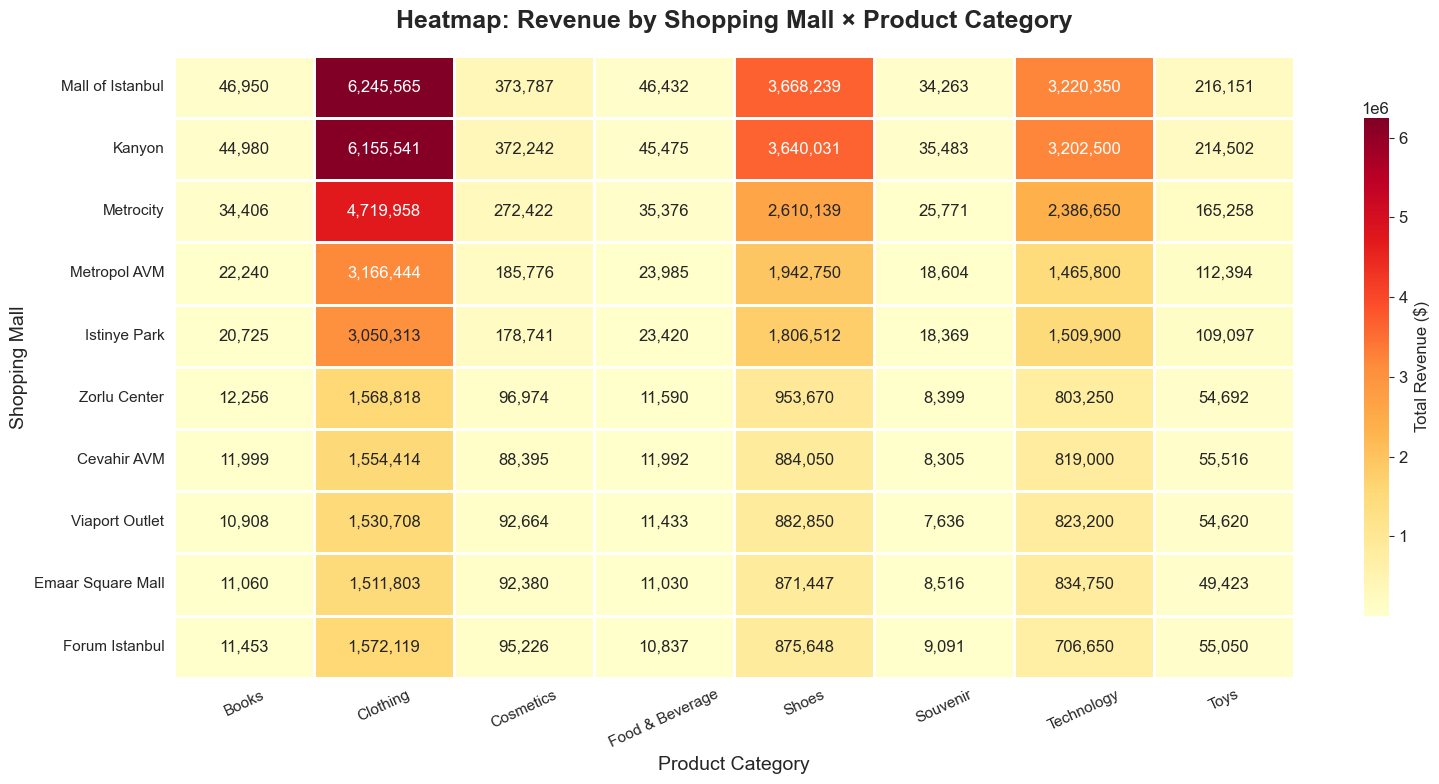

💾 Saved: chart1_heatmap_mall_category.png


In [15]:
# ─── CHART 1: Heatmap — Mall vs Category (Pivot Table) ───

pivot_heatmap = pivot_table.drop(columns='TOTAL')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot_heatmap,
    annot=True, fmt=',.0f',
    cmap='YlOrRd',
    linewidths=2, linecolor='white',
    cbar_kws={'label': 'Total Revenue ($)', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Heatmap: Revenue by Shopping Mall × Product Category',
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Product Category', fontsize=14)
ax.set_ylabel('Shopping Mall', fontsize=14)
ax.tick_params(axis='x', rotation=25, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()
plt.savefig('chart1_heatmap_mall_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart1_heatmap_mall_category.png')

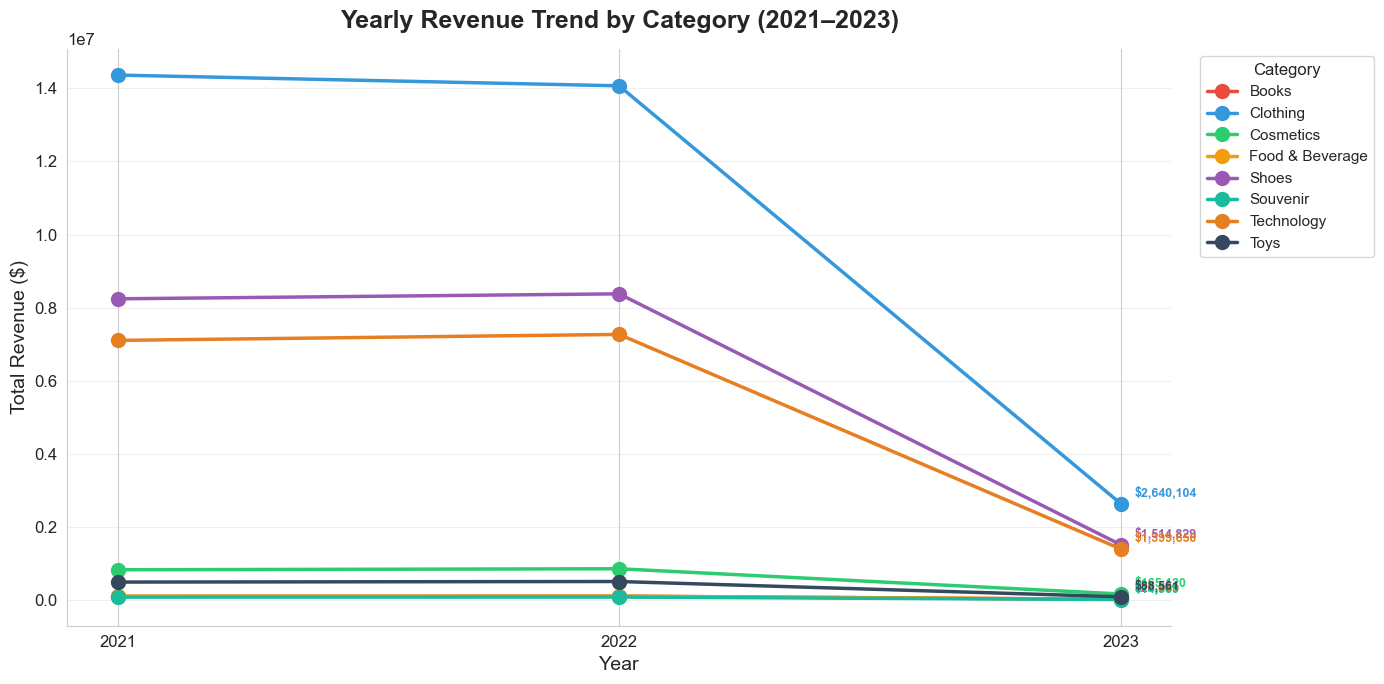

💾 Saved: chart2_yearly_trend_category.png


In [16]:
# ─── CHART 2: Line Chart — Yearly Revenue Trend per Category ───

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, ax = plt.subplots(figsize=(14, 7))

for i, category in enumerate(yearly_category.columns):
    ax.plot(
        yearly_category.index, yearly_category[category],
        marker='o', linewidth=2.5, markersize=10,
        color=colors[i], label=category
    )
    # Add value labels on last point
    last_val = yearly_category[category].iloc[-1]
    ax.annotate(
        f'${last_val:,.0f}',
        xy=(yearly_category.index[-1], last_val),
        xytext=(10, 5), textcoords='offset points',
        fontsize=9, fontweight='bold', color=colors[i]
    )

ax.set_title('Yearly Revenue Trend by Category (2021–2023)',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Total Revenue ($)', fontsize=14)
ax.set_xticks(yearly_category.index)
ax.legend(title='Category', fontsize=11, title_fontsize=12,
          bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_yearly_trend_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart2_yearly_trend_category.png')

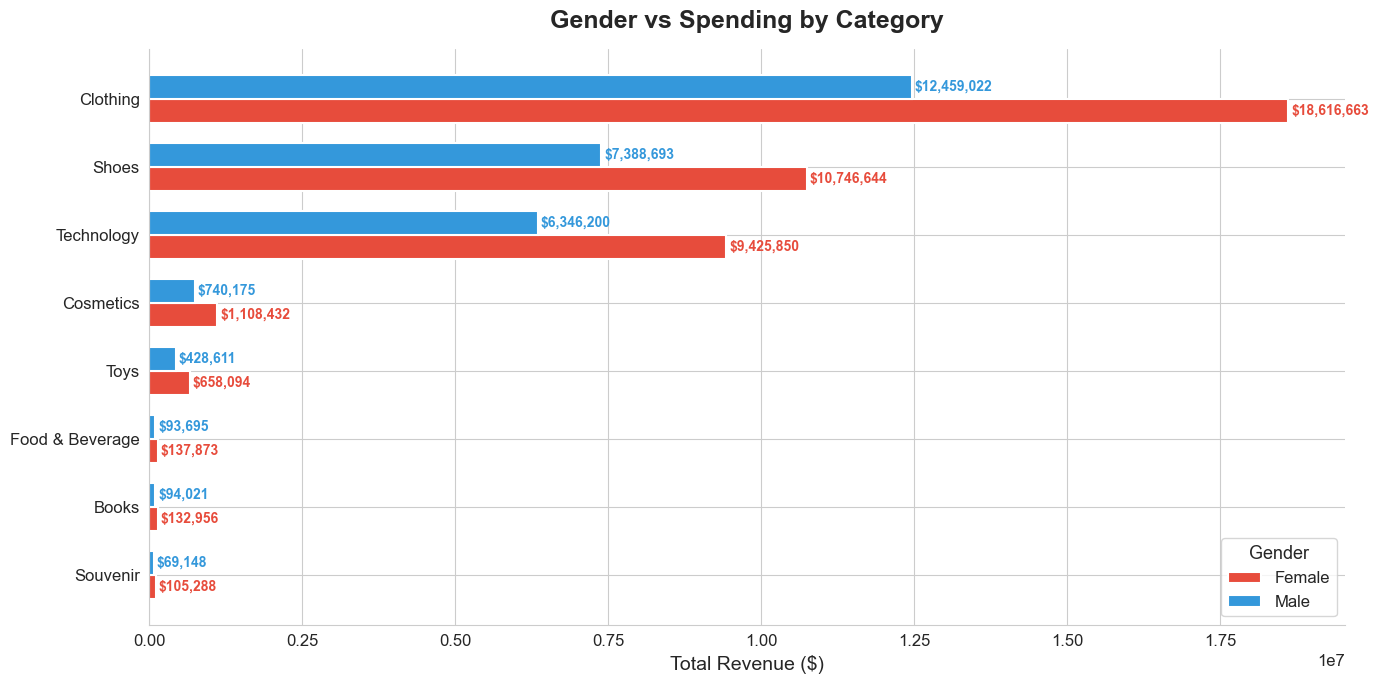

💾 Saved: chart3_gender_category_spending.png


In [17]:
# ─── CHART 3: Grouped Bar — Gender vs Spending by Category ───

gender_rev = df.pivot_table(values='price', index='category', columns='gender', aggfunc='sum').round(2)
gender_rev = gender_rev.sort_values('Female', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(gender_rev))
width = 0.35

bars1 = ax.barh([i - width/2 for i in x], gender_rev['Female'], width,
                color='#e74c3c', label='Female', edgecolor='white', linewidth=1.5)
bars2 = ax.barh([i + width/2 for i in x], gender_rev['Male'], width,
                color='#3498db', label='Male', edgecolor='white', linewidth=1.5)

# Add value labels
for bar in bars1:
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10, color='#e74c3c', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10, color='#3498db', fontweight='bold')

ax.set_yticks(x)
ax.set_yticklabels(gender_rev.index, fontsize=12)
ax.set_title('Gender vs Spending by Category',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue ($)', fontsize=14)
ax.legend(title='Gender', fontsize=12, title_fontsize=13, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_gender_category_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart3_gender_category_spending.png')

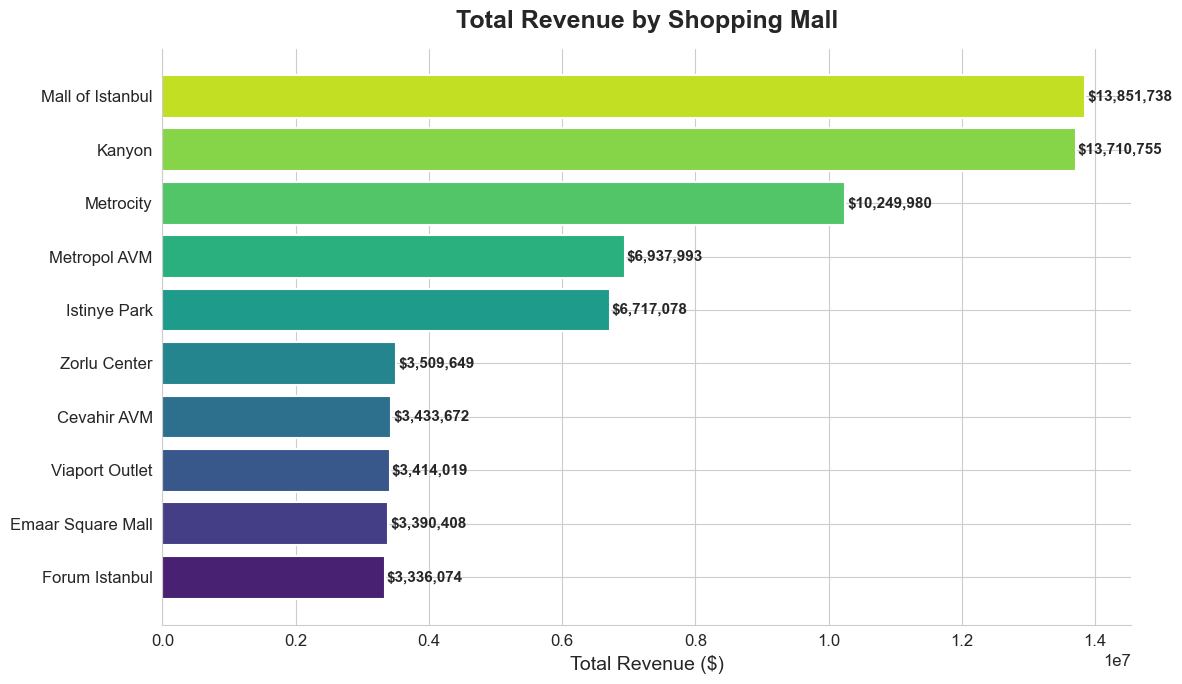

💾 Saved: chart4_revenue_by_mall.png


In [18]:
# ─── CHART 4: Bar Chart — Total Revenue by Shopping Mall ───

mall_rev = mall_analysis.sort_values('Total_Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    mall_rev.index, mall_rev['Total_Revenue'],
    color=sns.color_palette('viridis', len(mall_rev)),
    edgecolor='white', linewidth=1.5
)

for bar, val in zip(bars, mall_rev['Total_Revenue']):
    ax.text(bar.get_width() + 30000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11, fontweight='bold')

ax.set_title('Total Revenue by Shopping Mall',
             fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue ($)', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_revenue_by_mall.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart4_revenue_by_mall.png')

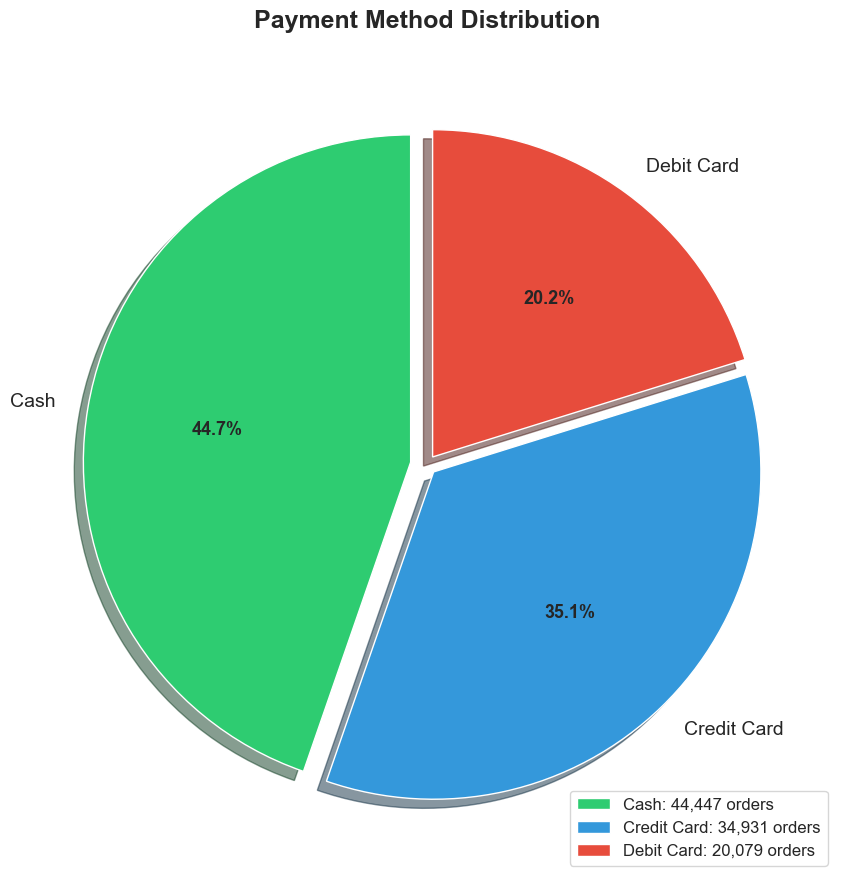

💾 Saved: chart5_payment_distribution.png


In [19]:
# ─── CHART 5: Pie Chart — Payment Method Distribution ───

payment_counts = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#3498db', '#e74c3c'],
    startangle=90,
    explode=(0.05, 0.03, 0.03),
    shadow=True,
    textprops={'fontsize': 14}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax.set_title('Payment Method Distribution', fontsize=18, fontweight='bold', pad=20)
legend_labels = [f'{label}: {count:,} orders' for label, count in zip(payment_counts.index, payment_counts.values)]
ax.legend(legend_labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig('chart5_payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart5_payment_distribution.png')

## 10. ⭐ Bonus Features

⭐ AVERAGE MONTH-OVER-MONTH REVENUE GROWTH RATE PER AVM
  📈 Emaar Square Mall            +1.35%
  📉 Zorlu Center                 -0.45%
  📉 Viaport Outlet               -1.09%
  📉 Cevahir AVM                  -1.12%
  📉 Forum Istanbul               -1.26%
  📉 Metrocity                    -1.77%
  📉 Metropol AVM                 -1.92%
  📉 Istinye Park                 -2.13%
  📉 Kanyon                       -2.56%
  📉 Mall of Istanbul             -3.09%


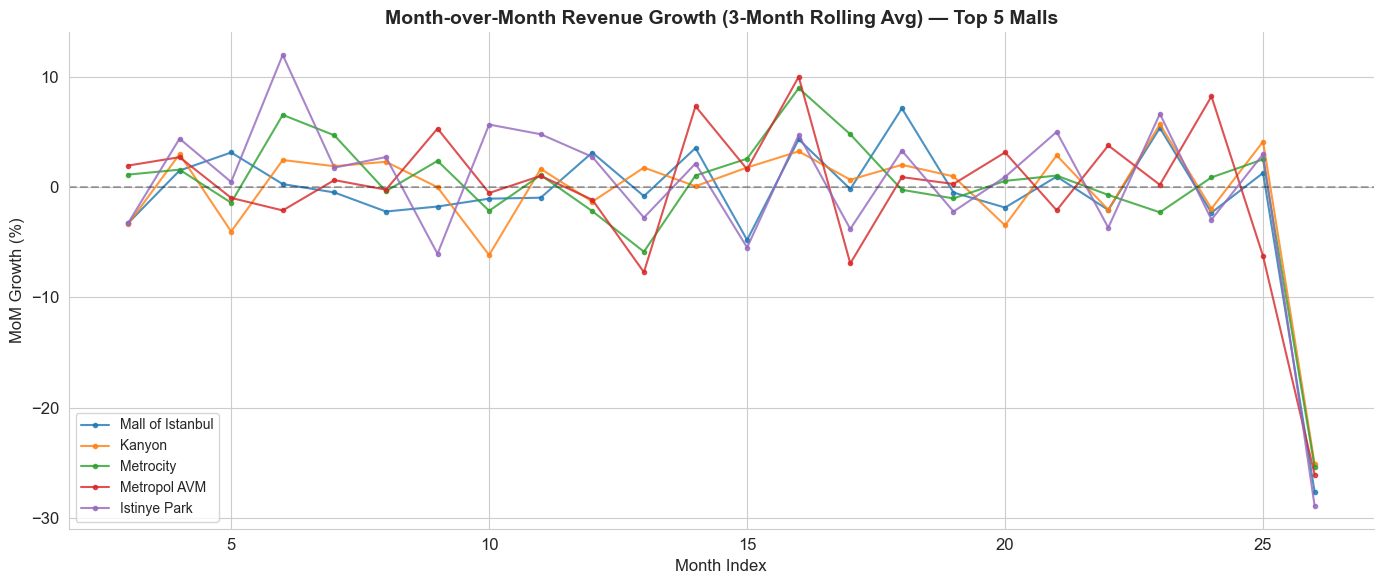

💾 Saved: chart6_mom_growth_top5.png


In [20]:
# ─── BONUS 1: Month-over-Month Revenue Growth Rate per AVM ───

monthly_mall = df.groupby(['year_month', 'shopping_mall'])['price'].sum().unstack().fillna(0)

# Calculate MoM growth for each mall
mom_growth = monthly_mall.pct_change().multiply(100).round(2)

# Show average monthly growth per mall
avg_mom = mom_growth.mean().sort_values(ascending=False).round(2)

print('⭐ AVERAGE MONTH-OVER-MONTH REVENUE GROWTH RATE PER AVM')
print('='*60)
for mall, growth in avg_mom.items():
    trend = '📈' if growth > 0 else '📉'
    print(f'  {trend} {mall:<25} {growth:>+8.2f}%')

# Plot MoM growth for top 5 malls
fig, ax = plt.subplots(figsize=(14, 6))
top5_malls = mall_analysis.head(5).index.tolist()

for mall in top5_malls:
    rolling = mom_growth[mall].rolling(3).mean()
    ax.plot(range(len(rolling)), rolling, marker='.', linewidth=1.5, label=mall, alpha=0.8)

ax.set_title('Month-over-Month Revenue Growth (3-Month Rolling Avg) — Top 5 Malls',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month Index', fontsize=12)
ax.set_ylabel('MoM Growth (%)', fontsize=12)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart6_mom_growth_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart6_mom_growth_top5.png')

⭐ DOMINANT PAYMENT METHOD PER CATEGORY
  💵 Books                     → Cash            (45.5%)
  💵 Clothing                  → Cash            (44.8%)
  💵 Cosmetics                 → Cash            (44.2%)
  💵 Food & Beverage           → Cash            (44.6%)
  💵 Shoes                     → Cash            (44.6%)
  💵 Souvenir                  → Cash            (44.2%)
  💵 Technology                → Cash            (44.7%)
  💵 Toys                      → Cash            (45.0%)


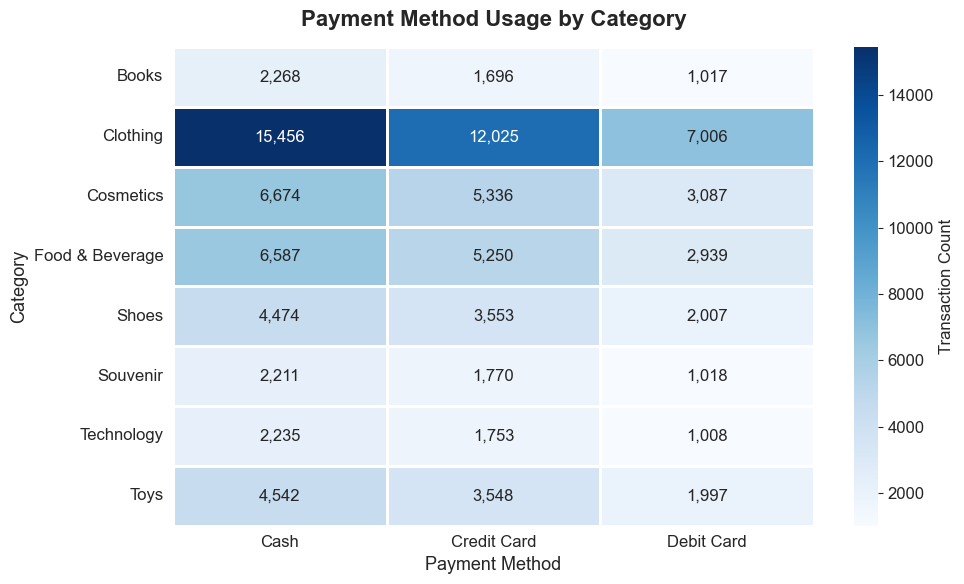

💾 Saved: chart7_payment_per_category.png


In [21]:
# ─── BONUS 2: Dominant Payment Method per Category ───

payment_category = df.groupby(['category', 'payment_method'])['invoice_no'].count().unstack().fillna(0)
payment_category['Dominant_Method'] = payment_category.idxmax(axis=1)
payment_category['Dominant_Count'] = payment_category.drop(columns='Dominant_Method').max(axis=1).astype(int)
payment_category['Dominant_Share_%'] = (
    payment_category['Dominant_Count'] /
    payment_category.drop(columns=['Dominant_Method', 'Dominant_Count', 'Dominant_Share_%'], errors='ignore').sum(axis=1) * 100
).round(1)

print('⭐ DOMINANT PAYMENT METHOD PER CATEGORY')
print('='*70)
for cat in payment_category.index:
    method = payment_category.loc[cat, 'Dominant_Method']
    share = payment_category.loc[cat, 'Dominant_Share_%']
    emoji = '💵' if method == 'Cash' else ('💳' if method == 'Credit Card' else '🏦')
    print(f'  {emoji} {cat:<25} → {method:<15} ({share}%)')

# Heatmap for payment method per category
payment_heatmap = df.pivot_table(
    values='invoice_no', index='category', columns='payment_method', aggfunc='count'
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    payment_heatmap, annot=True, fmt=',.0f',
    cmap='Blues', linewidths=2, linecolor='white',
    cbar_kws={'label': 'Transaction Count'}, ax=ax
)
ax.set_title('Payment Method Usage by Category', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Payment Method', fontsize=13)
ax.set_ylabel('Category', fontsize=13)

plt.tight_layout()
plt.savefig('chart7_payment_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: chart7_payment_per_category.png')

## 11. 💡 5 Actionable Business Insights for AVM Management

---

### Insight 1: Clothing Dominates Revenue — Leverage It for Cross-Selling
**Clothing** accounts for the largest share of transactions (~34%) and consistently leads in revenue across all malls and years. AVM management should **strategically place complementary categories** (Shoes, Cosmetics, Fashion accessories) near clothing sections and create themed shopping bundles to drive cross-category purchases.

### Insight 2: Technology Drives Highest Per-Transaction Value
Despite fewer transactions, **Technology** products command the highest average purchase amount (~$1,741 per transaction vs. ~$57 for Cosmetics). Malls should **allocate premium retail spaces** to tech brands, offer financing options, and host tech showcase events to attract high-value shoppers, especially during peak months.

### Insight 3: Female Customers Are the Core Revenue Driver
**Female customers** generate ~59.8% of all transactions and dominate spending across most categories. Malls should **tailor marketing campaigns** toward female demographics, expand women-focused product lines, and create female-friendly shopping experiences (lounges, events, loyalty programs targeted at women).

### Insight 4: Cash Remains King — But Digital Payment Adoption Is Growing
**Cash** is the dominant payment method (44.8%), followed by **Credit Card** (35.1%) and Debit Card (20.1%). Malls should **incentivize digital payments** through cashback offers and exclusive discounts for card users, while maintaining sufficient cash-handling infrastructure. The data suggests an opportunity to accelerate cashless transitions.

### Insight 5: 2022 Was the Peak Revenue Year — Understand the Drivers
**2022** saw the highest overall revenue across all categories, while 2023 data (partial year) shows a downward trend. Management should **analyze what drove 2022's success** (seasonal campaigns, economic factors, new store openings) and replicate those strategies. Proactive measures in 2023 such as flash sales, loyalty programs, and new brand introductions could help maintain momentum.

In [22]:
# ─── FINAL SUMMARY ───

print('\n' + '='*65)
print('📋 ANALYSIS SUMMARY')
print('='*65)
print(f'Total records analyzed:    {len(df):>10,}')
print(f'Date range:                {df["invoice_date"].min().strftime("%B %d, %Y")} → {df["invoice_date"].max().strftime("%B %d, %Y")}')
print(f'Total revenue:             ${df["price"].sum():>14,.2f}')
print(f'Avg purchase value:        ${df["price"].mean():>14,.2f}')
print(f'Shopping malls covered:    {df["shopping_mall"].nunique():>10}')
print(f'Product categories:        {df["category"].nunique():>10}')
print(f'Unique customers:          {df["customer_id"].nunique():>10,}')
print(f'Top category (revenue):    {category_analysis.index[0]:>20}')
print(f'Top mall (revenue):        {mall_analysis.index[0]:>20}')
print(f'Dominant payment:          {df["payment_method"].mode()[0]:>20}')
print(f'Gender majority:           {df["gender"].mode()[0]:>20} ({df["gender"].value_counts(normalize=True).iloc[0]*100:.1f}%)')
print('='*65)
print('✅ Multi-Dimensional Retail Analytics Complete!')


📋 ANALYSIS SUMMARY
Total records analyzed:        99,457
Date range:                January 01, 2021 → March 08, 2023
Total revenue:             $ 68,551,365.91
Avg purchase value:        $        689.26
Shopping malls covered:            10
Product categories:                 8
Unique customers:              99,457
Top category (revenue):                Clothing
Top mall (revenue):            Mall of Istanbul
Dominant payment:                          Cash
Gender majority:                         Female (59.8%)
✅ Multi-Dimensional Retail Analytics Complete!
